In [18]:
import importlib
import miaw
importlib.reload(miaw)
from miaw import FFNN
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.utils import check_random_state
from sklearn.metrics import accuracy_score
from visualizer import Visualizer


In [2]:
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)

random_state = check_random_state(0)
permutation = random_state.permutation(X.shape[0])
X = X[permutation]
y = y[permutation]
X = X.reshape((X.shape[0], -1))

# one-hot encode labels
encoder = OneHotEncoder(sparse_output=False, categories='auto')
y_encoded = encoder.fit_transform(y.reshape(-1, 1))

# train-test split
X_train, X_val, y_train, y_val = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

In [ ]:
miawlenteraModel = FFNN([784,128,64,10], ['relu','relu','softmax'],loss_function='cce', use_rmsnorm=False, reg_type="l2", weight_init='he')

history = miawlenteraModel.fit(X_train, y_train, epochs=10, batch_size=64, lr=0.05, verbose=0)

In [34]:
miaw_pred = miawlenteraModel.predict(X_val)
y_val_labels = np.argmax(y_val, axis=1)
# miaw_pred_labels = np.argmax(miaw_pred, axis=1)


accuracy = accuracy_score(y_val_labels, miaw_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")


Accuracy: 77.99%


In [26]:
miawlenteraModel.save('./models/new-noauto.json')

In [ ]:
testload = FFNN.load('./models/new-noauto.json')

miaw_p = testload.predict(X_val)
y_val_labels = np.argmax(y_val,axis=1)
miaw_pred_labels = np.argmax(miaw_p, axis=1)

accuracy_new = accuracy_score(y_val_labels,miaw_pred_labels)
print(f"Accuracy: {accuracy_new * 100:.2f}%")



Accuracy: 92.68%


In [8]:
print(history)

{'loss': [1.647615801379175, 0.557678777264375, 0.406731483106397, 0.3372054172537975, 0.2928465339620295, 0.2640002548423311, 0.24283902574096383, 0.22601371955214636, 0.21298133823866075, 0.20138916976493887], 'batch_losses': [[24.940077070625158, 24.469293024046816, 19.465522483191446, 21.581522435642114, 22.002926274420062, 20.543917096299857, 22.64782999268354, 14.71051460485583, 11.586655021579649, 11.176194808992179, 10.936449440024402, 8.157710480415533, 10.175967214876017, 9.115205425639584, 7.109249298545045, 7.671671107566256, 7.275700787795059, 7.439779922860459, 9.18673661512004, 6.94276795324039, 6.533296635714379, 6.518307200126198, 8.306146695281157, 4.788074404905185, 7.139312197579224, 3.504549639169641, 7.888385837242437, 6.879135528811007, 6.181946135935782, 5.926393235005764, 6.195345344417976, 7.173545700958714, 5.695796073524296, 3.892393098668097, 3.2116300037687466, 7.230713048430109, 3.556753356342506, 5.006845627147164, 2.9203566803098195, 5.68372570800355, 4

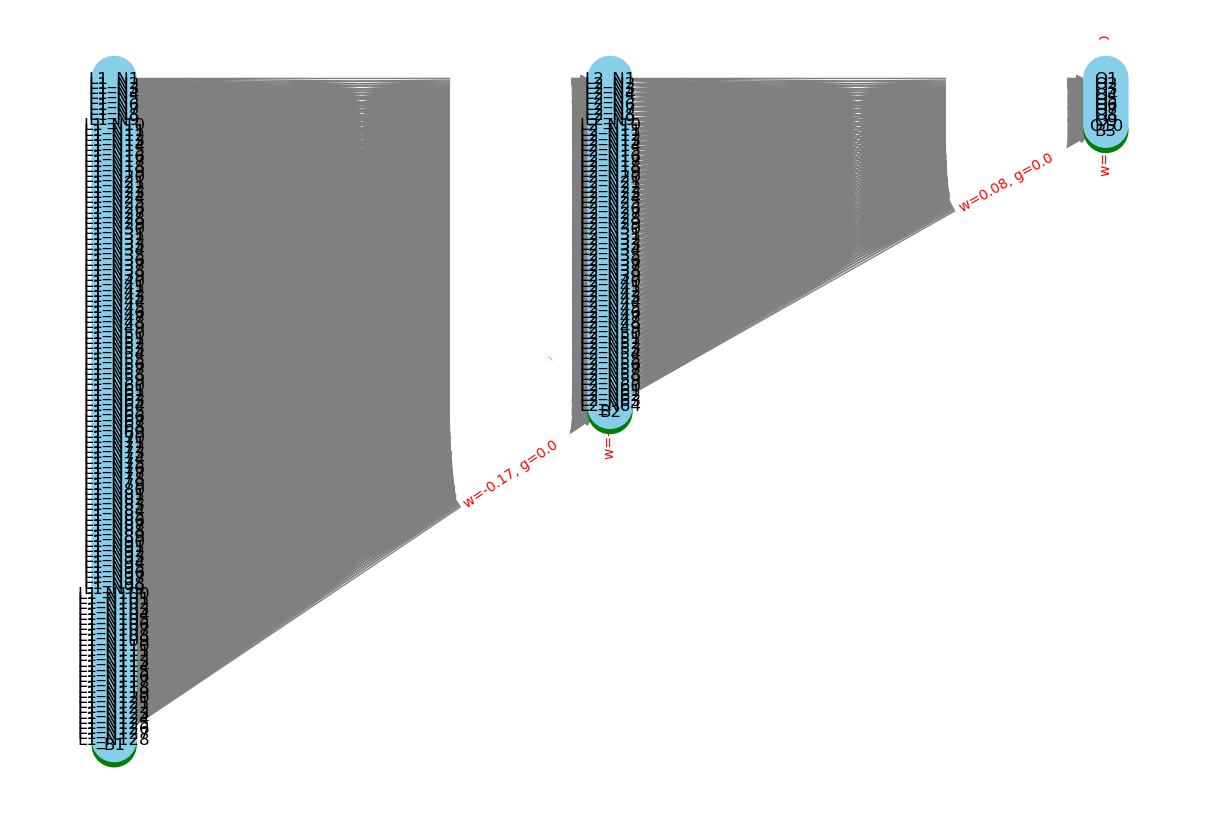

In [10]:
visualizer = Visualizer(miawlenteraModel)
visualizer.plot_neural_network()